In [1]:
#############################################
##### this is a test script for axolotl tracking 
##### modified based on the original code https://github.com/vivekhsridhar/tracktor/blob/master/examples/3g%20Zebrafish_schooling.ipynb
#############################################

In [8]:
import numpy as np
import pandas as pd
import tracktor as tr
import cv2
import sys
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import os
import math
from skimage.io import imread

## Global parameters
This cell (below) enlists user-defined parameters

In [9]:
# colours is a vector of BGR values which are used to identify individuals in the video
# since we only have one individual, the program will only use the first element from this array i.e. (0,0,255) - red
# number of elements in colours should be greater than n_inds (THIS IS NECESSARY FOR VISUALISATION ONLY)
n_inds = 1
#colours = [(255,0,0),(0,255,255),(255,0,255),(255,255,255),(255,255,0),(255,0,0),(0,255,0),(0,0,0)]
colours = [(0,0,255),(0,255,255),(255,0,255), (255,255,0),(255,0,0),(0,255,0)]


# this is the block_size and offset used for adaptive thresholding (block_size should always be odd)
# these values are critical for tracking performance
#block_size = 51
#offset = 20

# the scaling parameter can be used to speed up tracking if video resolution is too high (use value 0-1)
scaling = 1.0

# mot determines whether the tracker is being used in noisy conditions to track a single object or for multi-object
# using this will enable k-means clustering to force n_inds number of animals
mot = False

## parameters added for axolotl images
nb_skippedFrame = 500 # nb of frames to skip to make sure axolotl is there

threshold_value = 120 # threshold used in the gray image to detect axolotl

# minimum area and maximum area occupied by the animal in number of pixels
# this parameter is used to get rid of other objects in view that might be hard to threshold out but are differently sized
min_area = 100 
max_area = 800
min_circularity = 0.1 ## minimum circularity of object for detected animal

#### 
display_outFrame = True

In [10]:
# name of source video and paths
input_vidpath = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/Deinz_axolot_tracking/run_1/' # path to all video folders
output_dir = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/'
codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

if not os.path.exists(output_dir):
    os.mkdir(output_dir)

In [11]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names), print(len(folder_names))

['A15_1wpt_1_D1', 'A15_1wpt_2_L1', 'A15_1wpt_3_D2', 'A15_1wpt_4_D3', 'A15_1wpt_5_L2', 'A15_1wpt_6_L3', 'A15_4wpt_1_L1', 'A15_4wpt_2_D1', 'A15_4wpt_3_L2', 'A15_4wpt_4_D2', 'A15_4wpt_5_L3', 'A15_4wpt_6_D3', 'A15_6wpt_1_D1', 'A15_6wpt_2_L1', 'A15_6wpt_3_L2', 'A15_6wpt_4_D2', 'A15_6wpt_5_L3', 'A15_6wpt_6_D3', 'A15_8wpt_1_L1', 'A15_8wpt_2_D1', 'A15_8wpt_3_D2', 'A15_8wpt_4_D3', 'A15_8wpt_5_L2', 'A15_8wpt_6_L3', 'A15_preONT_1_D1', 'A15_preONT_2_L1', 'A15_preONT_3_L2', 'A15_preONT_4_D2', 'A15_preONT_5_L3', 'A15_preONT_6_D3', 'A27_1wpt_1_D1', 'A27_1wpt_2_D2', 'A27_1wpt_3_L1', 'A27_1wpt_4_L2', 'A27_1wpt_5_L3', 'A27_1wpt_6_D3', 'A27_4wpt_1_D1', 'A27_4wpt_2_L1', 'A27_4wpt_3_D2', 'A27_6wpt_1_L1', 'A27_4wpt_4_L2', 'A27_4wpt_5_L3', 'A27_4wpt_6_D3', 'A27_6wpt_2_L2', 'A27_6wpt_3_D1', 'A27_6wpt_4_D2', 'A27_6wpt_5_L3', 'A27_6wpt_6_D3', 'A27_8wpt_1_D1', 'A27_8wpt_2_L1', 'A27_8wpt_3_L2', 'A27_8wpt_4_D2', 'A27_8wpt_5_L3', 'A27_8wpt_6_D3', 'A27_preONT_1_L1', 'A27_preONT_2_L2', 'A27_preONT_3_L3', 'A27_preONT_

(None, None)

In [12]:
## test only specific video
#folder_names = folder_names[1]
#print(folder_names)
#if isinstance(folder_names, str):
#    folder_names = [folder_names]
#for folder in folder_names:
#    print(folder)

In [13]:
if isinstance(folder_names, str):
    folder_names = [folder_names]
    
for folder in folder_names:
    
    ## Start time
    start = time.time()
    
    print(folder)
    
    video = folder
    output_vidpath = output_dir + video + '.mp4'
    output_filepath = output_dir + video + '.csv'
    output_figpath = output_dir + video + '.pdf'
    output_error = output_dir + video + '_error.csv'
    output_circle = output_dir + video + '_circle.csv'
    
    video_path = Path(input_vidpath + folder + '/')
    first_file = next(p.name for p in video_path.iterdir() if p.is_file())
    #files = [p for p in video_path.iterdir() if p.is_file()]
    #first_file = files[0].name
    file_name = Path(first_file).stem
    #print(file_name)
    file_split = file_name.split("_")
    f_newname = "_".join(file_split[:-1])
    
    print(f_newname)
    #'1_D1_test/Basler_acA2040-120um__24899445__20260407_140424600_%04d.tiff'
    
    ##########
    # check first the shape of image to determine the scaling parameter
    ##########
    img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
    scaling_img = 300/img.shape[0]
    
    del img
    ###################################################
    ### loop over videos
    ###################################################
    ## Open video
    cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
    if cap.isOpened() == False:
        sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

    ## Video writer class to output video with contour and centroid of tracked object(s)
    # make sure the frame size matches size of array 'final'
    fourcc = cv2.VideoWriter_fourcc(*codec)
    output_framesize = (int(cap.read()[1].shape[1]*scaling_img),int(cap.read()[1].shape[0]*scaling_img))
    out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

    ## Individual location(s) measured in the last and current step
    meas_last = list(np.zeros((n_inds,2)))
    meas_now = list(np.zeros((n_inds,2)))
    
    last = 0
    df = []
    err = []
    
    ## first frame to detect the coordinate and radius of circles
    #cap.set(1,1)
    ## strat the tracing from the frame 500 to skip those without axolotl
    cap.set(1, nb_skippedFrame)
    
    ret, frame = cap.read()
    
    frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur_frame = cv2.medianBlur(gray_frame, 5)
    
    ## to adapt different number of piexls in the videos
    #minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
    #maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))
    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = minRadius_circle, maxRadius = maxRadius_circle)

    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 10, minRadius = 120, maxRadius = 150)
    circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
    circles = np.uint8(np.around(circles))
    
    print(circles)
    
    if len(circles) == 1:
        circle_run = circles[0,:][0]
        
        circle_x = circle_run[0]
        circle_y = circle_run[1]
        #circle_radius = circle_run[2] - 2
        circle_radius = 130
        
        circle_position = [circle_x, circle_y, circle_radius]
        
        circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
        circle_position.to_csv(output_circle, sep=',')
        
    else:
        print('zero or > 1 circles found ')
        break
    
    
    while(True):
        # Capture frame-by-frame
        ret, frame = cap.read()
        
        this = cap.get(1)
    
        if ret == True:
            frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
        
            # Apply mask to the area of interest
            mask = np.zeros(frame.shape)
            #mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
            #mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
            mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
            
            #frame[mask ==  0] = np.median(frame[mask >  0])
            frame[mask ==  0] = 0
        
            blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur = cv2.medianBlur(blur, 5)
            _, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
            #thresh = tr.colour_to_thresh(frame, block_size, offset)
            thresh = binary
            final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, 
                                                                               min_circularity = 0.1)
            
            try:
                row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
                final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
            except:
                print(this,  "frame Error")
                err.append([f_newname, this])
                
                continue
            
            # Create output dataframe
            for i in range(n_inds):
                df.append([this, meas_now[i][0], meas_now[i][1]])
        
            # Display the resulting frame
            out.write(final)
            cv2.imshow('frame', final)
            if cv2.waitKey(1) == 27:
                break
            #if display_outFrame:
               
            
        if last == this:
            break
    
        last = this
    
    ## Write positions to file
    df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
    df.to_csv(output_filepath, sep=',')

    if len(err) > 0:
        err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
        err.to_csv(output_error, sep=',')
    
    ## When everything done, release the capture
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

    ####################################
    # Plot tracks
    # The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
    ####################################
    df = pd.read_csv(output_filepath)
    
    
    plt.figure(figsize=(8, 8))
    plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
    plt.xlabel('pos_x')
    plt.ylabel('pos_y')
    plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
    plt.close()

    ## End time and duration
    end = time.time()
    duration = (end - start)/60
    
    print("--- %s minutes ---" %duration)
    

A15_1wpt_1_D1
Basler_acA2040-120um__24899445__20260407_092258990


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[[[144 152 139]]]
502.0 frame Error
503.0 frame Error
504.0 frame Error
505.0 frame Error
506.0 frame Error
507.0 frame Error
508.0 frame Error
509.0 frame Error
510.0 frame Error
511.0 frame Error
512.0 frame Error
513.0 frame Error
514.0 frame Error
515.0 frame Error
516.0 frame Error
517.0 frame Error
518.0 frame Error
519.0 frame Error
520.0 frame Error
521.0 frame Error
522.0 frame Error
523.0 frame Error
524.0 frame Error
525.0 frame Error
526.0 frame Error
527.0 frame Error
528.0 frame Error
529.0 frame Error
530.0 frame Error
531.0 frame Error
532.0 frame Error
533.0 frame Error
534.0 frame Error
535.0 frame Error
536.0 frame Error
537.0 frame Error
538.0 frame Error
539.0 frame Error
540.0 frame Error
541.0 frame Error
542.0 frame Error
543.0 frame Error
544.0 frame Error
545.0 frame Error
546.0 frame Error
547.0 frame Error
548.0 frame Error
549.0 frame Error
550.0 frame Error
551.0 frame Error
552.0 frame Error
553.0 frame Error
554.0 frame Error
555.0 frame Error
556.0 fram

KeyboardInterrupt: 

In [ ]:
###########################################################
###########################################################
## debug specific folder or file
###########################################################
###########################################################

In [8]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names)

['A15_1wpt_1_D1', 'A15_1wpt_2_L1', 'A15_1wpt_3_D2', 'A15_1wpt_4_D3', 'A15_1wpt_5_L2', 'A15_1wpt_6_L3', 'A15_4wpt_1_L1', 'A15_4wpt_2_D1', 'A15_4wpt_3_L2', 'A15_4wpt_4_D2', 'A15_4wpt_5_L3', 'A15_4wpt_6_D3', 'A15_6wpt_1_D1', 'A15_6wpt_2_L1', 'A15_6wpt_3_L2', 'A15_6wpt_4_D2', 'A15_6wpt_5_L3', 'A15_6wpt_6_D3', 'A15_8wpt_1_L1', 'A15_8wpt_2_D1', 'A15_8wpt_3_D2', 'A15_8wpt_4_D3', 'A15_8wpt_5_L2', 'A15_8wpt_6_L3', 'A15_preONT_1_D1', 'A15_preONT_2_L1', 'A15_preONT_3_L2', 'A15_preONT_4_D2', 'A15_preONT_5_L3', 'A15_preONT_6_D3', 'A27_1wpt_1_D1', 'A27_1wpt_2_D2', 'A27_1wpt_3_L1', 'A27_1wpt_4_L2', 'A27_1wpt_5_L3', 'A27_1wpt_6_D3', 'A27_4wpt_1_D1', 'A27_4wpt_2_L1', 'A27_4wpt_3_D2', 'A27_6wpt_1_L1', 'A27_4wpt_4_L2', 'A27_4wpt_5_L3', 'A27_4wpt_6_D3', 'A27_6wpt_2_L2', 'A27_6wpt_3_D1', 'A27_6wpt_4_D2', 'A27_6wpt_5_L3', 'A27_6wpt_6_D3', 'A27_8wpt_1_D1', 'A27_8wpt_2_L1', 'A27_8wpt_3_L2', 'A27_8wpt_4_D2', 'A27_8wpt_5_L3', 'A27_8wpt_6_D3', 'A27_preONT_1_L1', 'A27_preONT_2_L2', 'A27_preONT_3_L3', 'A27_preONT_

In [9]:
## test only specific video
folder_names = folder_names[0]
#print(folder_names)
if isinstance(folder_names, str):
    folder_names = [folder_names]
for folder in folder_names:
    print(folder)

A15_1wpt_1_D1


In [10]:
print(scaling_img)

0.5


In [32]:
input_vidpath
video = folder
output_vidpath = output_dir + video + '.mp4'
output_filepath = output_dir + video + '.csv'
output_figpath = output_dir + video + '.pdf'
output_error = output_dir + video + '_error.csv'


In [13]:
video_path = Path(input_vidpath + folder + '/')
first_file = next(p.name for p in video_path.iterdir() if p.is_file())
#files = [p for p in video_path.iterdir() if p.is_file()]
#first_file = files[0].name
file_name = Path(first_file).stem
#print(file_name)
file_split = file_name.split("_")
f_newname = "_".join(file_split[:-1])
    
print(f_newname)
    
cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')

if cap.isOpened() == False:
    sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'
fourcc = cv2.VideoWriter_fourcc(*codec)
output_framesize = (int(cap.read()[1].shape[1]*scaling_img),int(cap.read()[1].shape[0]*scaling_img))
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))

last = 0
df = []


Basler_acA2040-120um__24899445__20260407_092258990


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [14]:
cap.set(1,500)
threshold_value = 120
ret, frame = cap.read()

In [15]:
blur_frame.shape[1]/300

2.0

In [16]:
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur_frame = cv2.medianBlur(gray_frame, 5)
print(blur_frame.shape)

import math

#minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
#maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))


circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
#circles = np.uint8(np.around(circles))

print(circles)

(600, 600)
None


In [28]:
np.around(circles)

array([[[290., 304., 278.]]], dtype=float32)

In [29]:
minRadius_circle

240

In [ ]:
src = frame
if circles is not None:
    circles = np.uint8(np.around(circles))
    for i in circles[0, :]:
        center = (i[0], i[1])
        # circle center
        cv2.circle(src, center, 1, (0, 100, 100), 3)
        # circle outline
        radius = i[2]
        cv2.circle(src, center, radius, (255, 0, 255), 3)

cv2.imshow("detected circles", src)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
#cap.set(1, nb_skippedFrame)

In [20]:
while(True):
    # Capture frame-by-frame
    ret, frame = cap.read()  
    this = cap.get(1)
    print(this)
    if ret == True:
        frame = cv2.resize(frame, None, fx = scaling, fy = scaling, interpolation = cv2.INTER_LINEAR)
        
        
        # Apply mask to the area of interest
        mask = np.zeros(frame.shape)
        #mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
        mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
        #frame[mask ==  0] = np.median(frame[mask >  0])
        frame[mask ==  0] = 0
        
        blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.medianBlur(blur, 5)
        _, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
        #thresh = tr.colour_to_thresh(frame, block_size, offset)
        thresh = binary
        final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area)
        row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
        final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
        
        # Create output dataframe
        for i in range(n_inds):
            df.append([this, meas_now[i][0], meas_now[i][1]])
        
        # Display the resulting frame
        out.write(final)
        cv2.imshow('frame', final)
        if cv2.waitKey(1) == 27:
            break
            
    if last == this:
        break
    
    last = this

501.0


ValueError: XA must be a 2-dimensional array.

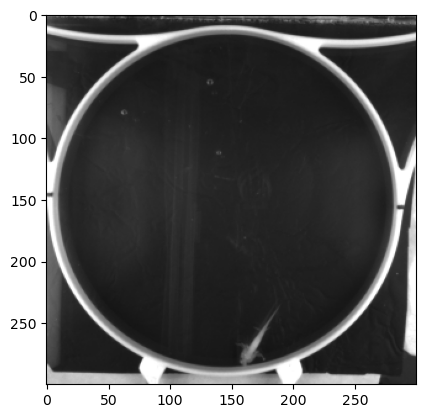

In [18]:
ret, frame = cap.read()
frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
plt.imshow(frame,'gray')

In [19]:
cap.set(1, 500)
ret, frame = cap.read()  
this = cap.get(1)
print(this)

501.0


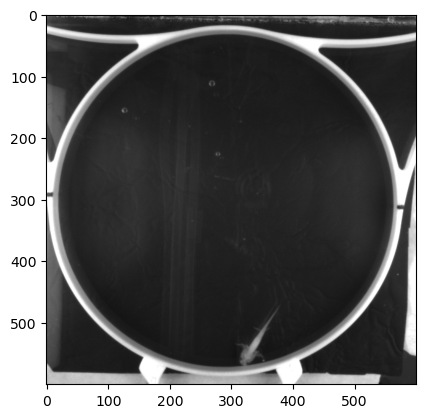

In [19]:
plt.imshow(frame,'gray')

In [20]:
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur_frame = cv2.medianBlur(gray_frame, 5)

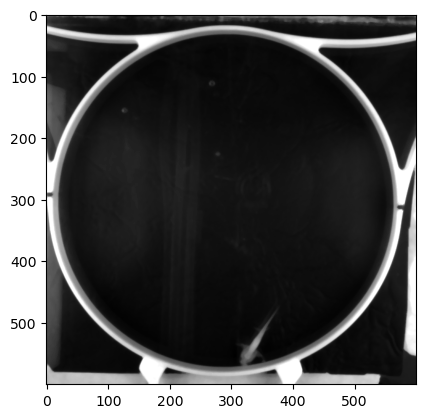

In [21]:
plt.imshow(blur_frame,'gray')

In [23]:
minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))
print([minRadius_circle, maxRadius_circle])

[240, 280]


In [26]:
circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius =minRadius_circle , maxRadius = maxRadius_circle)
circles = np.uint8(np.around(circles))
print(circles)

[[[34 48 22]]]


In [25]:
circle_run = circles[0,:][0]
print(circle_run)

[290.5 303.5 278.3]


In [26]:
circle_run = circles[0,:][0]
circle_x = circle_run[0]
circle_y = circle_run[1]
circle_radius = 130

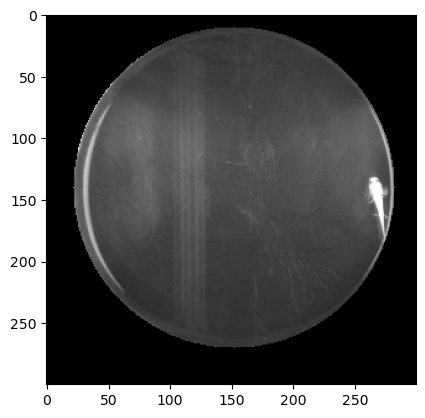

In [27]:
# Apply mask to the area of interest
mask = np.zeros(frame.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
frame[mask ==  0] = 0
plt.imshow(frame,'gray')

In [32]:
len(circles)

1

In [29]:
circles

array([[[154, 140, 132]]], dtype=uint8)

1

In [43]:
xx = circles[0,:][0]
xx[0]

np.uint8(154)

In [43]:
threshold_value

120

0.641141357875468
0.24605794237128514
0.5429913228426803
0.7539822368615503
0.6269475859030688
0.14453295234499872
0.06233569259069313


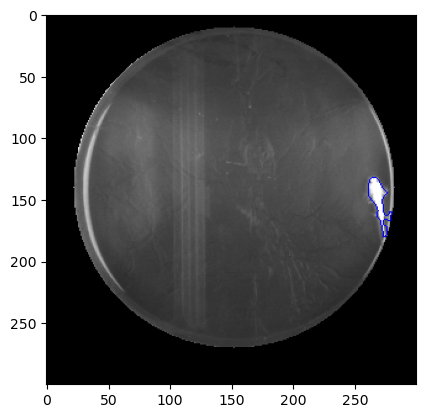

In [53]:
blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur = cv2.medianBlur(blur, 5)

_, binary = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY)
#thresh = tr.colour_to_thresh(frame, block_size, offset)
thresh = binary
final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
plt.imshow(final,'gray')

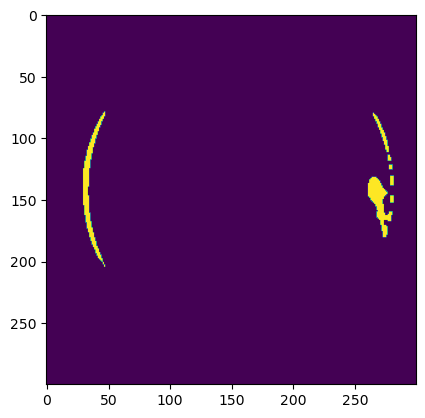

In [54]:
plt.imshow(binary)

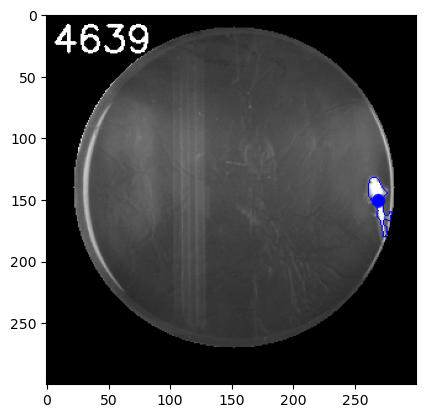

In [55]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
plt.imshow(final,'gray')

In [27]:
threshold_value = 115
threshold_value_adaptive = np.percentile(blur, 99.)
threshold_value_adaptive, threshold_value

(np.float64(115.0), 115)

In [30]:
300*300*0.22/100

198.0

(100, 800)

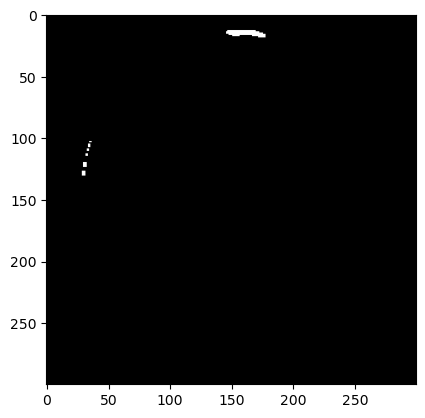

In [29]:
plt.imshow(binary,'gray')
min_area, max_area

In [ ]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
        final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)